<a href="https://colab.research.google.com/github/davidlealo/seminario_recsys_2026/blob/main/codigo_seminario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Usamos IA para estudiar: https://notebooklm.google.com/notebook/d939dd8b-cfe9-4878-9cb9-c57c054badd9

También para mejorar la ppt y para correr el código en este colab: https://drive.google.com/file/d/14Ad4h-xa3fC0iG5XtgJNw2JNHunhO2Pa/view?usp=drive_link

# Seminario DLPR — Simulador KSS en funcionamiento

Reproducción del entorno de simulación del paper *"Item-Difficulty-Aware Learning Path
Recommendation: From a Real Walking Perspective"* (Zhang et al., KDD 2024).

Este notebook clona el código oficial de los autores, resuelve sus dependencias y
ejecuta el **simulador de estudiantes (entorno KSS)** para ilustrar la idea central
del paper: el aprendizaje solo es efectivo cuando se respeta el orden de prerrequisitos.

## 1. Clonar el repositorio oficial

Descargamos el código de los autores desde GitHub (`sosweetzhang/DLPR`).
Contiene dos partes: `EduSim/` (el simulador de estudiantes) e `IDALPR/` (el modelo DLPR).

In [1]:
!git clone https://github.com/sosweetzhang/DLPR.git
%cd DLPR
# (alternativa con wget del zip:)
# !wget https://github.com/sosweetzhang/DLPR/archive/refs/heads/main.zip && unzip main.zip

Cloning into 'DLPR'...
remote: Enumerating objects: 218, done.
remote: Counting objects: 100% (218/218), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 218 (delta 43), reused 138 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (218/218), 36.41 MiB | 24.53 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/DLPR


## 2. Instalar dependencias

El repo no trae `requirements.txt`, así que instalamos a mano las librerías que usa:
`gym` (entorno de RL), `longling`, `networkx` (el grafo de conceptos), etc.
El aviso rojo sobre `dopamine-rl` / `gym` es inofensivo: es un paquete preinstalado de
Colab y no afecta nuestro código.

In [2]:
!pip install -q "gym==0.26.2" longling tensorboardX networkx tqdm scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 28.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.2/141.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


## 3. Explorar la estructura del repo

Imprimimos el árbol de carpetas para ubicar las piezas clave: el entorno KSS
(`EduSim/Envs/KSS/`), el modelo de Knowledge Tracing (`IDALPR/KT.py`) y los datos.

In [7]:
import os

ROOT = "/content/DLPR"
for dirpath, dirnames, filenames in os.walk(ROOT):
    # ignorar .git y __pycache__
    dirnames[:] = [d for d in dirnames if d not in (".git", "__pycache__")]
    depth = dirpath.replace(ROOT, "").count(os.sep)
    indent = "    " * depth
    print(f"{indent}{os.path.basename(dirpath)}/")
    for f in sorted(filenames):
        print(f"{indent}    {f}    →  {os.path.join(dirpath, f)}")

DLPR/
    LICENSE    →  /content/DLPR/LICENSE
    README.md    →  /content/DLPR/README.md
    IDALPR/
        AC.py    →  /content/DLPR/IDALPR/AC.py
        AdaptiveCN.py    →  /content/DLPR/IDALPR/AdaptiveCN.py
        CN.py    →  /content/DLPR/IDALPR/CN.py
        DLPR.py    →  /content/DLPR/IDALPR/DLPR.py
        KT.py    →  /content/DLPR/IDALPR/KT.py
        PPO.py    →  /content/DLPR/IDALPR/PPO.py
        __init__.py    →  /content/DLPR/IDALPR/__init__.py
        rl_utils.py    →  /content/DLPR/IDALPR/rl_utils.py
    examples/
        KSS.py    →  /content/DLPR/examples/KSS.py
        knowledge_structure.csv    →  /content/DLPR/examples/knowledge_structure.csv
        tutorial.py    →  /content/DLPR/examples/tutorial.py
    EduSim/
        __init__.py    →  /content/DLPR/EduSim/__init__.py
        _init_.py    →  /content/DLPR/EduSim/_init_.py
        spaces/
            SimpleSpace.py    →  /content/DLPR/EduSim/spaces/SimpleSpace.py
            __init__.py    →  /content/DLPR/Edu

## 4. Parches de compatibilidad

El código fue escrito para versiones antiguas de las librerías. Aplicamos dos arreglos
mínimos para que corra en el Python actual de Colab:

- **`longling.ML` → `longling.ml`**: en la versión nueva de `longling` el módulo cambió de
  mayúsculas a minúsculas.
- **`collections.Iterable` → `collections.abc.Iterable`**: se movió de lugar en Python 3.10+.

In [4]:
# longling 1.4.x: el toolkit pasó de ML (mayúsc.) a ml (minúsc.)
!grep -rl 'longling.ML' EduSim | xargs sed -i 's/longling\.ML/longling.ml/g'
# Python 3.11/3.12: collections.Iterable se movió a collections.abc
!sed -i 's/from collections import Iterable/from collections.abc import Iterable/' EduSim/Envs/meta/ItemBase.py
print("parches aplicados ✓")

parches aplicados ✓


## 5. Crear los datos del entorno KSS

El repo no incluye los archivos de datos del entorno KSS, así que los creamos:

- **`knowledge_structure.csv`**: el grafo de prerrequisitos entre 10 conceptos
  (ej.: para aprender el concepto 4 hay que dominar antes el 2, 3 y 5).
- **`configuration.json`**, **`learning_order.json`**, **`items.json`**: parámetros
  del simulador, orden de aprendizaje y los ejercicios (con su dificultad).

In [8]:
import os, json
d = "/content/DLPR/EduSim/Envs/KSS/meta_data"
os.makedirs(d, exist_ok=True)

# configuration.json
with open(f"{d}/configuration.json", "w") as f:
    json.dump({"order_ratio": 1.0, "initial_steps": 20, "review_times": 1,
               "binary_scorer": True, "exam_sum": True}, f, indent=2)

# learning_order.json
with open(f"{d}/learning_order.json", "w") as f:
    json.dump([5, 0, 1, 2, 3, 4, 6, 7, 8, 9], f)

# knowledge_structure.csv  (aristas de prerrequisitos del grafo de 10 conceptos)
with open(f"{d}/knowledge_structure.csv", "w") as f:
    f.write("0,1\n0,2\n1,3\n2,4\n2,8\n3,4\n4,8\n5,4\n5,9\n6,7\n7,8\n8,9\n")

# items.json  (ítem i -> concepto i)
with open(f"{d}/items.json", "w") as f:
    json.dump({str(i): {"knowledge": i} for i in range(10)}, f, indent=2)

print("creados:", sorted(os.listdir(d)))

creados: ['configuration.json', 'items.json', 'knowledge_structure.csv', 'learning_order.json']


### 5.1 Ítems con dificultad

El entorno de DLPR espera **5 ejercicios por concepto** con distintos niveles de
dificultad (0 a 4) — esto es justo el componente *"item-difficulty-aware"* del título.
Generamos 50 ítems (10 conceptos × 5 niveles) con su dificultad.

> Son datos **reconstruidos** por nosotros (el repo no los publicó): sirven para
> demostrar la mecánica del simulador, no para reproducir los números exactos del paper.

In [15]:
import json
d = "/content/DLPR/EduSim/Envs/KSS/meta_data"
items = {}
for i in range(50):
    items[str(i)] = {"knowledge": i % 10, "difficulty": float(i // 10)}  # 5 ítems/concepto, dificultad 0-4
with open(f"{d}/items.json", "w") as f:
    json.dump(items, f, indent=2)
print("items.json regenerado:", len(items), "ítems")

items.json regenerado: 50 ítems


## 6. Construir el entorno

Instanciamos el simulador KSS. Reemplazamos el modelo neuronal de Knowledge Tracing
por uno "dummy" (un stub), porque la versión completa requiere un checkpoint entrenado
que el repo no incluye — y para esta demo no lo necesitamos.

El entorno expone 10 conceptos (acciones posibles) y un **orden topológico**: una
secuencia válida que respeta todos los prerrequisitos.

In [16]:
import torch
import EduSim.Envs.KSS.Env as kss_env_mod

class _DummyKT:
    def forward_state(self, ques, ans):
        return torch.zeros(1, max(len(ques), 1), 10)
kss_env_mod.Agent_KT = lambda *a, **k: _DummyKT()   # evita cargar el checkpoint

# instanciar la clase directamente (sin gym.make -> sin el verificador de gym 0.26)
env = kss_env_mod.KSSEnv(seed=10)
print("N° de conceptos:", env.action_space.n)
print("Orden topológico:", list(env._topo_order))

N° de conceptos: 10
Orden topológico: [0, 5, 6, 1, 2, 7, 3, 4, 8, 9]


## 7. Primer experimento: camino ordenado vs. aleatorio

Simulamos 200 estudiantes y comparamos dos formas de recomendar el camino:
en **orden topológico** (respetando prerrequisitos) vs. en **orden aleatorio**.

> Nota: esta comparación es **ruidosa** (estudiantes y objetivos aleatorios, recompensas
> pequeñas) y no es el experimento real del paper, que entrena un agente de RL.
> El experimento determinista de abajo ilustra el punto de forma mucho más clara.

In [18]:
import numpy as np

def correr_episodio(env, estrategia="topo"):
    env.begin_episode()
    if estrategia == "topo":
        orden = list(env._topo_order)
    else:
        orden = list(env.random_state.permutation(list(env._topo_order)))
    camino = [str(c) for c in orden]          # los IDs de ítem son strings
    env.n_step(camino)
    _, reward, _, info = env.end_episode()
    return reward

for estrategia in ["topo", "random"]:
    rewards = [correr_episodio(env, estrategia) for _ in range(200)]
    print(f"camino '{estrategia}': efectividad media Eₚ = {np.mean(rewards):.3f}")

camino 'topo': efectividad media Eₚ = 0.022
camino 'random': efectividad media Eₚ = 0.053


In [19]:
import math

G = env.knowledge_structure
concepto = 4
preds = list(G.predecessors(concepto))
print(f"Concepto {concepto} — prerrequisitos: {preds}\n")

def ganancia(prereqs_dominados: bool):
    learner = next(env.learners)
    estado = learner._state
    for i in range(len(estado)):
        estado[i] = -3.0                       # nada dominado
    if prereqs_dominados:
        for p in preds:
            estado[p] = 5.0                    # prerrequisitos dominados
    learner.learning_model._ks_last_visit = None
    antes = estado[concepto]
    learner.learn(env.test_item_base[str(concepto)])   # estudia el concepto (modelo real)
    return estado[concepto] - antes

print(f"Ganancia estudiando {concepto} SIN prerrequisitos dominados: {ganancia(False):.5f}")
print(f"Ganancia estudiando {concepto} CON prerrequisitos dominados: {ganancia(True):.5f}")

Concepto 4 — prerrequisitos: [2, 3, 5]

Ganancia estudiando 4 SIN prerrequisitos dominados: 0.00000
Ganancia estudiando 4 CON prerrequisitos dominados: 4.00000


## 8. El mensaje central del paper (demostración determinista)

Aquí mostramos, **sin ruido**, la idea clave de DLPR usando el modelo real del estudiante.

Medimos cuánto se aprende un concepto en dos situaciones:
- **Sin prerrequisitos dominados** → ganancia ≈ **0** (barras rojas).
- **Con prerrequisitos dominados** → ganancia ≈ **4** (barras verdes).

**Conclusión:** estudiar un concepto sin la base necesaria es casi inútil; recomendar
el orden correcto (y la dificultad adecuada) es lo que hace efectivo el aprendizaje.
Esto es el *"real walking perspective"*: no se puede saltar, hay que **caminar paso a
paso sobre terreno firme**.

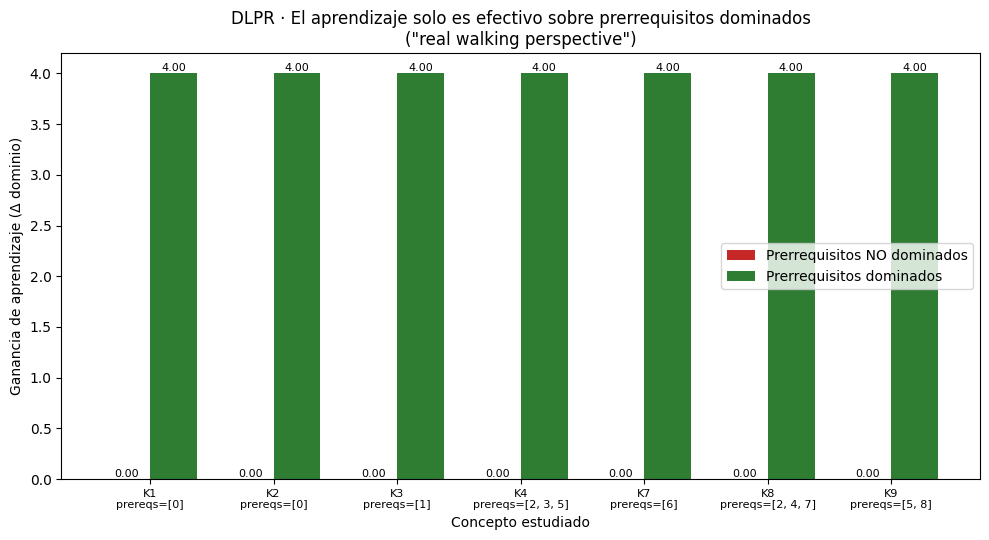

Figura guardada en /content/dlpr_prerrequisitos.png (descárgala del panel de archivos)


In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt

G = env.knowledge_structure

def ganancia(concepto, prereqs_dominados):
    preds = list(G.predecessors(concepto))
    learner = next(env.learners)
    estado = learner._state
    for i in range(len(estado)):
        estado[i] = -3.0
    if prereqs_dominados:
        for p in preds:
            estado[p] = 5.0
    learner.learning_model._ks_last_visit = None
    antes = estado[concepto]
    learner.learn(env.test_item_base[str(concepto)])
    return estado[concepto] - antes

conceptos = sorted(c for c in G.nodes if list(G.predecessors(c)))
sin = [ganancia(c, False) for c in conceptos]
con = [ganancia(c, True)  for c in conceptos]

x, w = np.arange(len(conceptos)), 0.38
fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - w/2, sin, w, label="Prerrequisitos NO dominados", color="#C62828")
b2 = ax.bar(x + w/2, con, w, label="Prerrequisitos dominados",   color="#2E7D32")
ax.set_xlabel("Concepto estudiado")
ax.set_ylabel("Ganancia de aprendizaje (Δ dominio)")
ax.set_title('DLPR · El aprendizaje solo es efectivo sobre prerrequisitos dominados\n("real walking perspective")')
ax.set_xticks(x)
ax.set_xticklabels([f"K{c}\nprereqs={list(G.predecessors(c))}" for c in conceptos], fontsize=8)
ax.bar_label(b1, fmt="%.2f", fontsize=8)
ax.bar_label(b2, fmt="%.2f", fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig("/content/dlpr_prerrequisitos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en /content/dlpr_prerrequisitos.png (descárgala del panel de archivos)")

## El grafo de prerrequisitos del entorno KSS

Este es el **mapa de conceptos** sobre el que el estudiante simulado debe aprender.
Cada nodo (K0…K9) es un concepto, y cada flecha va de un **prerrequisito** hacia el
**concepto que depende de él**: por ejemplo, `K2 → K3` significa que hay que dominar K2
antes de poder aprender K3 de forma efectiva.

Se lee de arriba hacia abajo:
- **Arriba** (K0, K5, K6): conceptos básicos, sin prerrequisitos. Son los puntos de partida.
- **Abajo** (K8, K9): conceptos avanzados, que solo se aprenden bien tras dominar varias bases.
- La cadena **K0 → K2 → K3 → K4 → K8 → K9** muestra la ruta más larga: hay que recorrer
  toda esa secuencia, paso a paso, para llegar a los conceptos finales.

**Por qué importa para DLPR:** este grafo es la estructura que el recomendador debe
respetar. No puede sugerir K8 si el estudiante aún no domina K2, K4 y K7. Recomendar una
ruta es, literalmente, **encontrar un camino válido por este grafo** (un orden topológico)
adaptado al nivel y la dificultad de cada estudiante — el "caminar paso a paso sobre
terreno firme" del paper.

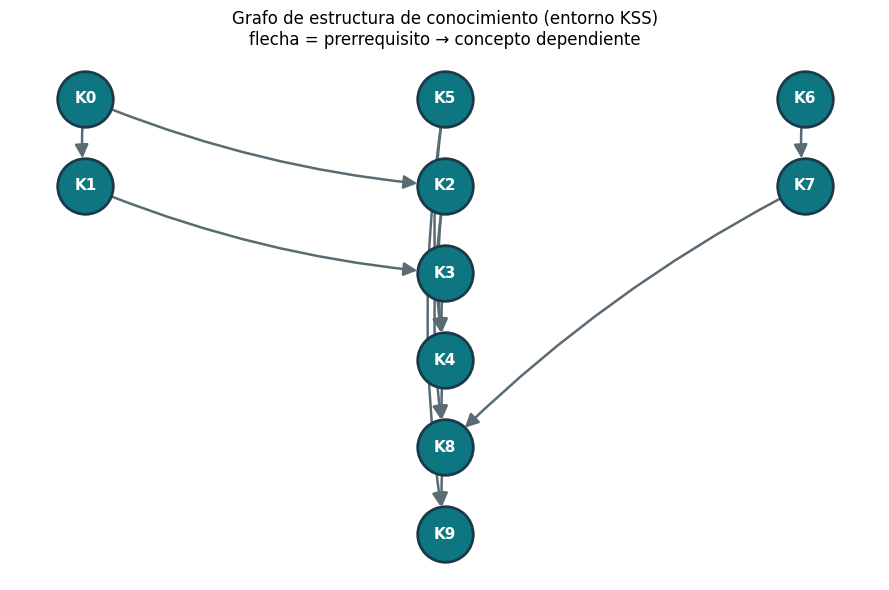

Guardado en /content/grafo_kss.png


In [21]:
import networkx as nx
import matplotlib.pyplot as plt

G = env.knowledge_structure          # el grafo real del entorno KSS que ya tienes cargado

# Layout jerárquico por "generaciones topológicas" (niveles de prerrequisito)
layers = list(nx.topological_generations(G))
pos = {}
for li, layer in enumerate(layers):
    for ni, node in enumerate(sorted(layer)):
        pos[node] = (ni - (len(layer)-1)/2, -li)

fig, ax = plt.subplots(figsize=(9, 6))
nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle="-|>", arrowsize=20,
                       edge_color="#5B6B73", width=1.8, node_size=1600,
                       connectionstyle="arc3,rad=0.08")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1600, node_color="#0D7680",
                       edgecolors="#1A3A4A", linewidths=2)
nx.draw_networkx_labels(G, pos, ax=ax, labels={n: f"K{n}" for n in G.nodes},
                        font_color="white", font_size=11, font_weight="bold")
ax.set_title("Grafo de estructura de conocimiento (entorno KSS)\nflecha = prerrequisito → concepto dependiente", fontsize=12)
ax.axis("off"); plt.tight_layout()
plt.savefig("/content/grafo_kss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en /content/grafo_kss.png")

## Experimento: el orden de recomendación determina la eficiencia

Simulamos un mismo estudiante (partiendo sin dominar nada) y le hacemos "caminar" por
los 10 conceptos en tres órdenes distintos, midiendo su dominio promedio paso a paso:

- **Topológico** (verde): respeta los prerrequisitos → el dominio sube rápido y temprano.
- **Aleatorio** (naranjo): se estanca al principio y recupera a mitad de camino.
- **Inverso** (rojo): viola los prerrequisitos → los primeros pasos no producen ningún
  aprendizaje (ganancia 0), porque intenta conceptos avanzados sin la base.

Los tres terminan parecido (al final cubren todo el grafo), pero lo importante es la
**eficiencia**: con un presupuesto limitado de pasos (línea punteada en 5), el orden
topológico ya alcanzó su techo mientras el inverso sigue en cero.

**Conclusión:** recomendar bien no es solo *qué* enseñar, sino *en qué orden*. Ese es el
problema que DLPR resuelve aprendiendo a recomendar rutas que respetan la estructura de
prerrequisitos y la dificultad — el "real walking perspective".

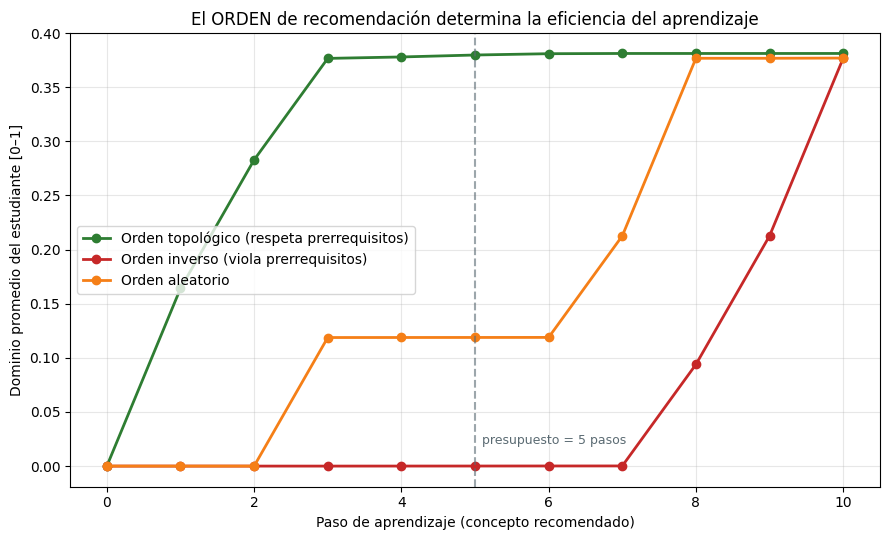

In [22]:
import networkx as nx, matplotlib.pyplot as plt, random

G = env.knowledge_structure
N = G.number_of_nodes()

def dominio_promedio(state):
    return sum(min(max((s + 3) / 8, 0), 1) for s in state) / N   # normaliza [-3,5] -> [0,1]

def caminar(orden):
    learner = next(env.learners)
    state = learner._state
    for i in range(N): state[i] = -3.0                # baseline: nada dominado
    traj = [dominio_promedio(state)]
    for k in orden:
        learner.learning_model._ks_last_visit = None  # aislar el efecto del orden
        learner.learn(env.test_item_base[str(k)])      # modelo real del estudiante
        traj.append(dominio_promedio(state))
    return traj

topo = list(nx.topological_sort(G))
rev  = list(reversed(topo))
random.seed(0); rnd = topo[:]; random.shuffle(rnd)

plt.figure(figsize=(9, 5.5))
for nombre, orden, c in [("Orden topológico (respeta prerrequisitos)", topo, "#2E7D32"),
                         ("Orden inverso (viola prerrequisitos)",      rev,  "#C62828"),
                         ("Orden aleatorio",                            rnd,  "#F57F17")]:
    t = caminar(orden)
    plt.plot(range(len(t)), t, marker="o", label=nombre, color=c, linewidth=2)
plt.axvline(5, ls="--", color="#5B6B73", alpha=.6)
plt.text(5.1, .02, "presupuesto = 5 pasos", color="#5B6B73", fontsize=9)
plt.xlabel("Paso de aprendizaje (concepto recomendado)")
plt.ylabel("Dominio promedio del estudiante [0–1]")
plt.title("El ORDEN de recomendación determina la eficiencia del aprendizaje")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig("/content/experimento_walking.png", dpi=150, bbox_inches="tight")
plt.show()

## Métricas comparativas de las estrategias de ruta

Tres formas de medir la calidad de una ruta de aprendizaje:

| Métrica | Qué mide |
|---|---|
| **Efectividad Eₚ** | Dominio total que gana el estudiante (de 0 a 1). |
| **Pasos → umbral** | Cuántos conceptos necesita para alcanzar un nivel de dominio dado. |
| **Eficiencia (AUC)** | Área bajo la curva de aprendizaje: cuánto sabía, en promedio, a lo largo del camino. |

**Lectura clave:** la *efectividad final* es casi idéntica en las tres estrategias (todas
terminan cubriendo el grafo), pero el orden topológico alcanza el umbral en **3 pasos** vs.
los **10** del inverso, y es **~5× más eficiente** (AUC 0.32 vs 0.06).

> La calidad de una recomendación no está en el destino, sino en la **eficiencia del camino**.
> Por eso DLPR no recomienda solo *qué* estudiar, sino *en qué orden* y con qué dificultad.

In [23]:
import networkx as nx, random
import pandas as pd

G = env.knowledge_structure
N = G.number_of_nodes()
UMBRAL = 0.35   # nivel de dominio objetivo

def dominio_promedio(state):
    return sum(min(max((s + 3) / 8, 0), 1) for s in state) / N

def caminar(orden):
    learner = next(env.learners)
    state = learner._state
    for i in range(N): state[i] = -3.0
    traj = [dominio_promedio(state)]
    for k in orden:
        learner.learning_model._ks_last_visit = None
        learner.learn(env.test_item_base[str(k)])
        traj.append(dominio_promedio(state))
    return traj

topo = list(nx.topological_sort(G))
rev  = list(reversed(topo))
random.seed(0); rnd = topo[:]; random.shuffle(rnd)

filas = []
for nombre, orden in [("Topológico", topo), ("Aleatorio", rnd), ("Inverso", rev)]:
    t = caminar(orden)
    Ep    = t[-1] - t[0]                                              # efectividad: dominio ganado
    pasos = next((i for i, v in enumerate(t) if v >= UMBRAL), None)   # pasos hasta el umbral
    auc   = sum(t) / len(t)                                           # eficiencia (área bajo curva)
    filas.append({
        "Estrategia": nombre,
        "Efectividad Eₚ": round(Ep, 3),
        f"Pasos → {UMBRAL}": pasos if pasos is not None else "no llega",
        "Eficiencia (AUC)": round(auc, 3),
    })

tabla = pd.DataFrame(filas).set_index("Estrategia")
print(tabla.to_string())
tabla   # en Colab se muestra como tabla bonita

            Efectividad Eₚ  Pasos → 0.35  Eficiencia (AUC)
Estrategia                                                
Topológico           0.381             3             0.317
Aleatorio            0.377             8             0.165
Inverso              0.377            10             0.062


,Efectividad Eₚ,Pasos → 0.35,Eficiencia (AUC)
Estrategia,,,
Topológico,0.381,3,0.317
Aleatorio,0.377,8,0.165
Inverso,0.377,10,0.062


## Los dos agentes de DLPR

DLPR es un modelo **jerárquico de dos agentes** que cooperan:

- **L-Agent (Learning Agent)** — implementado con **PPO**. Decide *qué concepto* enseñar
  a continuación recorriendo el grafo de prerrequisitos, y le pasa al P-Agent dos cosas:
  la **tolerancia** (cuántos ejercicios practicar) y la **dificultad** inicial.
- **P-Agent (Practice Agent)** — implementado con **Actor-Critic**. Dado el concepto y la
  dificultad pedida, elige el *ejercicio concreto* a resolver.

Esto conecta las dos mitades del título del paper: *"Learning Path Recommendation"* (L-Agent,
el camino por el grafo) e *"Item-Difficulty-Aware"* (P-Agent, la dificultad del ejercicio).

In [24]:
import torch, networkx as nx, sys
sys.path.append('/content/DLPR/IDALPR')
from PPO import PPO
from AC import ActorCritic

# --- dimensiones (igual que en DLPR.py) ---
state_dim = action_dim = env.action_space.n      # 10 conceptos
hidden_dim, device = 128, torch.device('cpu')

# --- instanciar los dos agentes del paper ---
L_agent = PPO(state_dim, hidden_dim, action_dim, 1e-3, 1e-3, 0.95, 10, 0.2, 0.98, device, 128)
P_agent = ActorCritic(state_dim, hidden_dim, action_dim, 1e-3, 1e-3, 0.98,
                      env.learning_item_base.knowledge2item, device, 128)
print("✓ L-Agent (PPO) y P-Agent (Actor-Critic) instanciados\n")

# --- grafo de conocimiento + un estudiante simulado ---
Know_G = nx.DiGraph(); Know_G.add_edges_from(list(env.knowledge_structure.edges))
learner = next(env.learners)
L_state = torch.tensor([[min(max((s+3)/8, 0), 1) for s in learner._state]], dtype=torch.float32)
target = list(learner.target)
print("Estudiante simulado — conceptos objetivo:", target)
print("Dominio inicial por concepto:", [round(float(x),2) for x in L_state[0]], "\n")

# --- PASO 1: el L-Agent decide QUÉ concepto, con qué tolerancia y dificultad ---
last_item = 0
know, tolerance, init_diff = L_agent.take_action(
    L_state, last_item, target, Know_G, k_hop=1, threshhold=0.6, last_tor=6, last_prac_num=5)
print(f"L-Agent → concepto K{know}  |  tolerancia (n° de ejercicios)={tolerance}  |  dificultad objetivo={init_diff:.2f}")

# --- PASO 2: el P-Agent elige el EJERCICIO concreto de ese concepto con esa dificultad ---
ques = P_agent.take_action(know, L_state, init_diff)
item = env.learning_item_base.index[str(ques)]
print(f"P-Agent → ejercicio #{ques}  (concepto K{item.knowledge}, dificultad {item.difficulty})")

✓ L-Agent (PPO) y P-Agent (Actor-Critic) instanciados

Estudiante simulado — conceptos objetivo: [np.int64(9), np.int64(3), np.int64(5), np.int64(1)]
Dominio inicial por concepto: [0.0, 0.24, 0.0, 0.09, 0.08, 0.0, 0.05, 0.16, 0.0, 0.0] 

L-Agent → concepto K0  |  tolerancia (n° de ejercicios)=8  |  dificultad objetivo=0.00
P-Agent → ejercicio #0  (concepto K0, dificultad 0.0)


### Un paso de recomendación coordinada

Instanciamos los dos agentes reales del repo y les damos un estudiante simulado.
El L-Agent elige el concepto + tolerancia + dificultad; el P-Agent elige el ejercicio
específico de ese concepto con esa dificultad.

> Los agentes están **recién inicializados (sin entrenar)**, así que la política aún no es
> óptima — pero es el mecanismo real del paper, y la selección de concepto ya respeta el
> grafo gracias a la "navegación cognitiva adaptativa" del L-Agent.

In [26]:
import torch, networkx as nx

Know_G = nx.DiGraph(); Know_G.add_edges_from(list(env.knowledge_structure.edges))
learner = next(env.learners)
target = list(learner.target)
print("Conceptos objetivo del estudiante:", target, "\n")

def estado_actual():
    return torch.tensor([[min(max((s+3)/8, 0), 1) for s in learner._state]], dtype=torch.float32)

last_item, last_tor, last_prac = 0, 6, 5
print(f"{'Paso':<5}{'L-Agent: concepto':<20}{'dificultad':<12}{'tolerancia':<12}{'P-Agent: ejercicio':<20}")
print("-"*70)

for paso in range(1, 9):
    L_state = estado_actual()
    know, tol, diff = L_agent.take_action(L_state, last_item, target, Know_G,
                                          k_hop=1, threshhold=0.6, last_tor=last_tor, last_prac_num=last_prac)
    ques = P_agent.take_action(know, L_state, diff)
    item = env.learning_item_base.index[str(ques)]

    # el estudiante "practica" (modelo real): actualizamos su dominio
    learner.learning_model._ks_last_visit = None
    for _ in range(int(tol)):
        learner.learn(item)

    print(f"{paso:<5}K{know:<19}{diff:<12.2f}{int(tol):<12}#{ques} (K{item.knowledge}, dif {item.difficulty})")
    last_item, last_tor, last_prac = know, tol, int(tol)

print("\nDominio final por concepto:", [round(float(x),2) for x in estado_actual()[0]])
print("Objetivos:", target)

Conceptos objetivo del estudiante: [np.int64(0), np.int64(9), np.int64(3)] 

Paso L-Agent: concepto   dificultad  tolerancia  P-Agent: ejercicio  
----------------------------------------------------------------------
1    K0                  0.12        7           #0 (K0, dif 0.0)
2    K1                  0.55        11          #11 (K1, dif 1.0)
3    K0                  0.99        1           #10 (K0, dif 1.0)
4    K1                  1.00        1           #11 (K1, dif 1.0)
5    K0                  1.00        1           #10 (K0, dif 1.0)
6    K1                  1.00        1           #11 (K1, dif 1.0)
7    K0                  1.00        1           #10 (K0, dif 1.0)
8    K1                  1.00        1           #11 (K1, dif 1.0)

Dominio final por concepto: [1.0, 1.0, 0.54, 0.53, 0.39, 0.0, 0.0, 0.04, 0.46, 0.11]
Objetivos: [np.int64(0), np.int64(9), np.int64(3)]


### Una ruta de aprendizaje completa (varios pasos L → P)

Encadenamos varios pasos: en cada uno el L-Agent recomienda un concepto y el P-Agent un
ejercicio, el estudiante "practica" (actualizamos su dominio con el modelo real del
simulador) y el ciclo continúa. Así se ve cómo progresa la ruta y cómo sube el dominio.